
# IT Ticket Triage — Notebook-first Project

Этот ноутбук — **главный файл проекта**. Здесь ты увидишь:

1. **Очень подробный EDA** (много графиков): распределения, пропуски, временные тренды, текстовые закономерности, дубли и шум разметки.
2. **Обучение модели** (train/test split по времени), метрики, confusion matrix.
3. **Explainability**: какие слова/фразы влияют на предсказание (глобально и локально).
4. **Retrieval похожих тикетов** без дублей (и почему раньше могло показывать 3 одинаковых).
5. **Policy слой** (hard rules), который спасает “критичные” кейсы вроде *«у меня украли 100к долларов»*.
6. **GPT (Transformer)**: 
   - генерирует объяснение + next steps в **строгом JSON**
   - может быть fallback, если ML не уверен (novel/out-of-domain тикеты)
7. **Сохранение артефактов** в `../artifacts/`, которые использует Streamlit `app.py`.

> ⚠️ Важно: датасет `synthetic_it_support_tickets.csv` **синтетический и сильно шаблонный** — в EDA мы это докажем.


In [68]:

# === Setup & Imports ===
import os
import re
import json
import math
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
import joblib

# Reproducibility
np.random.seed(42)

PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "customer_support_tickets.csv"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)


PROJECT_ROOT: /Users/artemkim/Downloads/it_ticket_triage_project_v3
DATA_PATH: /Users/artemkim/Downloads/it_ticket_triage_project_v3/data/customer_support_tickets.csv
ARTIFACTS_DIR: /Users/artemkim/Downloads/it_ticket_triage_project_v3/artifacts


In [69]:
# === Load dataset ===
# Expected location (project layout): ../data/customer_support_tickets.csv
# If you run this notebook elsewhere, we try a couple of fallbacks.

df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)
display(df.head(3))

# --- Standardize columns to match the rest of this notebook (keep downstream cells unchanged) ---
# Text
df["initial_message"] = (df["Ticket_Subject"].fillna("").astype(str)
                         + "\n\n"
                         + df["Ticket_Description"].fillna("").astype(str))

# Priority mapping -> {low, medium, high, urgent}
_priority_map = {
    "Low": "low",
    "Medium": "medium",
    "High": "high",
    "Critical": "urgent",
}
df["priority"] = df["Priority_Level"].map(_priority_map).fillna(df["Priority_Level"].astype(str).str.lower())

# Time
df["created_at"] = df["Submission_Date"]

# Categories (map to existing notebook naming)
df["issue_type"] = df["Issue_Category"].fillna("unknown").astype(str)
df["product_area"] = df["Ticket_Channel"].fillna("unknown").astype(str)
df["channel"] = df["Ticket_Channel"].fillna("unknown").astype(str)

# Optional fields used in notebook (create if missing)
df["csat_score"] = pd.to_numeric(df.get("Satisfaction_Score"), errors="coerce")
df["resolution_time_hours"] = pd.to_numeric(df.get("Resolution_Time_Hours"), errors="coerce")
df["platform"] = df.get("Ticket_Channel", "unknown").fillna("unknown").astype(str)
df["customer_segment"] = "unknown"
df["region"] = np.nan

print("\nStandardized shape:", df.shape)
display(df[["initial_message","priority","created_at","issue_type","product_area","channel"]].head(3))


Raw shape: (20000, 12)


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5



Standardized shape: (20000, 23)


,initial_message,priority,created_at,issue_type,product_area,channel
0,"Hours of operation - Individual\n\nHi Support,...",high,2025-07-02,General Inquiry,Web Form,Web Form
1,"Data not syncing - Card\n\nHi Support, The app...",high,2025-06-28,Technical,Chat,Chat
2,"2FA issues - Question\n\nHi Support, How do I ...",high,2025-02-05,Account,Web Form,Web Form


In [70]:

# === Basic schema ===
display(df.dtypes)
display(df.describe(include='all').T.head(25))


Ticket_ID                 object
Customer_Name             object
Customer_Email            object
Ticket_Subject            object
Ticket_Description        object
Issue_Category            object
Priority_Level            object
Ticket_Channel            object
Submission_Date           object
Resolution_Time_Hours      int64
Assigned_Agent            object
Satisfaction_Score         int64
initial_message           object
priority                  object
created_at                object
issue_type                object
product_area              object
channel                   object
csat_score                 int64
resolution_time_hours      int64
platform                  object
customer_segment          object
region                   float64
dtype: object

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticket_ID,20000,20000,TKT-100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,20000,17900,William Smith,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Email,20000,19489,njohnson@example.com,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket_Subject,20000,13943,Login failed - Ever,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket_Description,20000,20000,"Hi Support, Where is your headquarters located...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issue_Category,20000,5,Technical,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Priority_Level,20000,4,Low,7716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket_Channel,20000,3,Chat,6693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Submission_Date,20000,731,2025-05-11,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Resolution_Time_Hours,20000.0,NaN,NaN,NaN,39.2303,35.221884,1.0,11.0,27.0,58.0,120.0



## 1) EDA — Missing values

Смотрим долю пропусков. Это важно для:
- выбора признаков
- понимания, что можно использовать в triage (на момент создания тикета)


,missing_rate,missing_pct
region,1.0,100.0
initial_message,0.0,0.0
customer_segment,0.0,0.0
platform,0.0,0.0
resolution_time_hours,0.0,0.0
csat_score,0.0,0.0
channel,0.0,0.0
product_area,0.0,0.0
issue_type,0.0,0.0
created_at,0.0,0.0


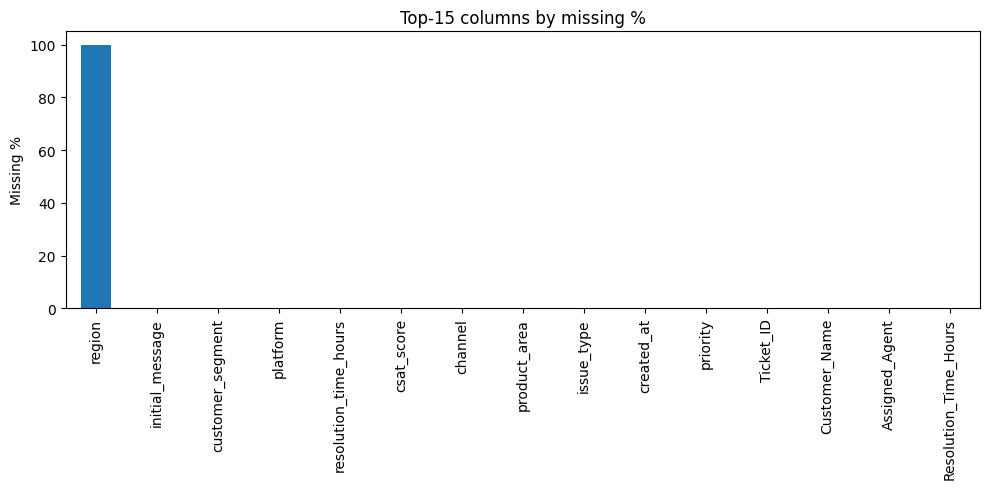

In [71]:

missing = df.isna().mean().sort_values(ascending=False)
missing_df = pd.DataFrame({"missing_rate": missing, "missing_pct": (missing*100).round(2)})
display(missing_df)

plt.figure(figsize=(10,5))
missing_df["missing_pct"].head(15).plot(kind="bar")
plt.title("Top-15 columns by missing %")
plt.ylabel("Missing %")
plt.tight_layout()
plt.show()



## 2) EDA — Время и объём

Проверим временной диапазон и динамику тикетов.


Min created_at: 2024-01-02 00:00:00
Max created_at: 2026-01-01 00:00:00


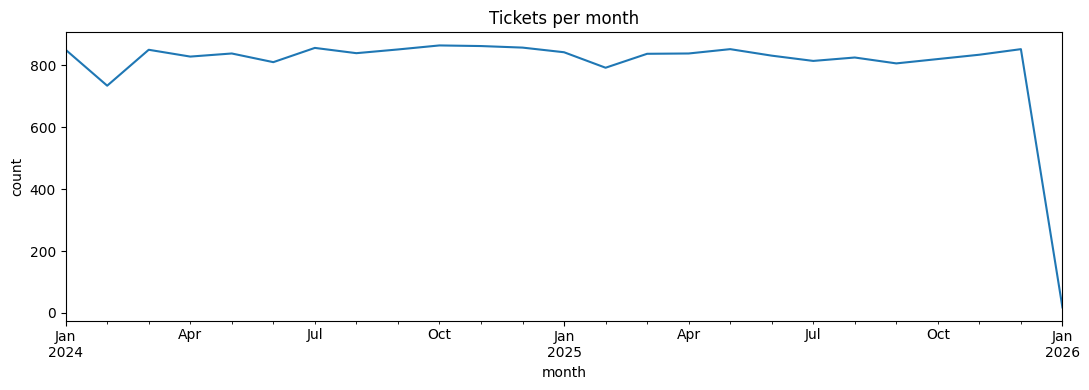

In [72]:

df["created_at_dt"] = pd.to_datetime(df["created_at"], errors="coerce")
print("Min created_at:", df["created_at_dt"].min())
print("Max created_at:", df["created_at_dt"].max())

tmp = df.dropna(subset=["created_at_dt"]).copy()
tmp["month"] = tmp["created_at_dt"].dt.to_period("M").dt.to_timestamp()

tickets_by_month = tmp.groupby("month").size()

plt.figure(figsize=(11,4))
tickets_by_month.plot(kind="line")
plt.title("Tickets per month")
plt.ylabel("count")
plt.tight_layout()
plt.show()



## 2.1) EDA — Priority во времени

Смотрим, меняется ли распределение приоритетов по месяцам.


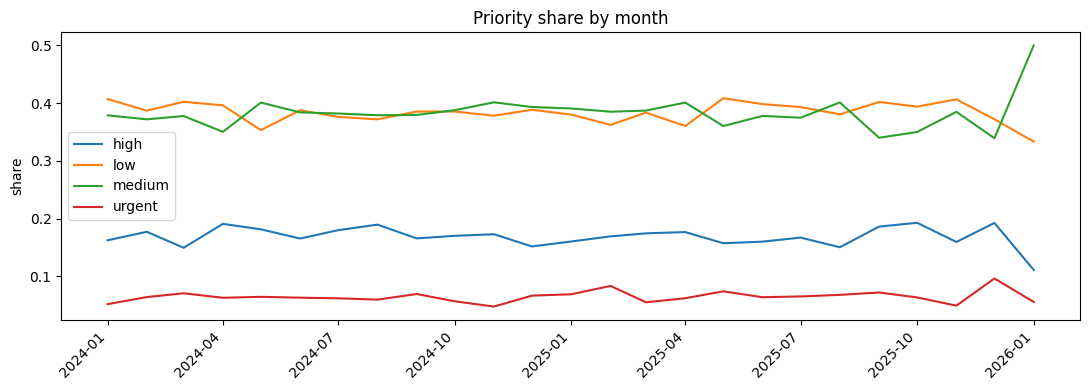

In [73]:

tmp = df.dropna(subset=["created_at_dt"]).copy()
tmp["month"] = tmp["created_at_dt"].dt.to_period("M").dt.to_timestamp()

prio_by_month = pd.crosstab(tmp["month"], tmp["priority"], normalize="index").sort_index()

plt.figure(figsize=(11,4))
for col in prio_by_month.columns:
    plt.plot(prio_by_month.index, prio_by_month[col], label=col)
plt.title("Priority share by month")
plt.ylabel("share")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()



## 2.2) EDA — Reopened / Attachments по priority

Смотрим, есть ли связь между приоритетом и:
- reopen
- наличием вложений



## 2.3) EDA — CSAT по priority


/var/folders/gl/96ss4btd7y5781v8lrfb_xcm0000gn/T/ipykernel_39320/423520143.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


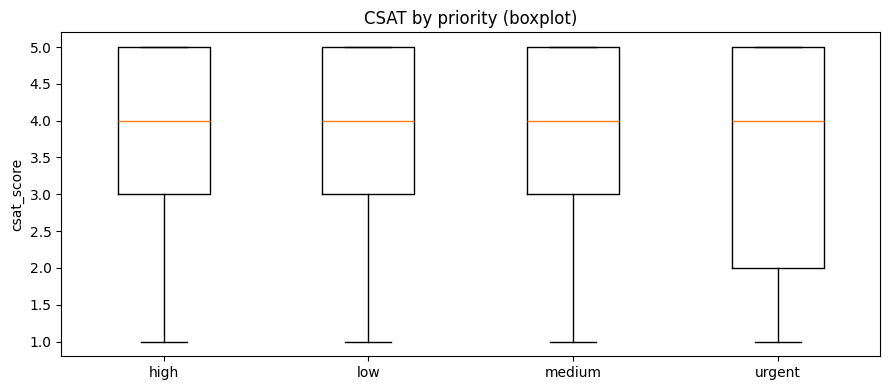

In [74]:

csat_df = df.dropna(subset=["csat_score"]).copy()
labels = sorted(df["priority"].unique())
groups = [csat_df.loc[csat_df["priority"] == p, "csat_score"].values for p in labels]
plt.figure(figsize=(9,4))
plt.boxplot(groups, labels=labels)
plt.title("CSAT by priority (boxplot)")
plt.ylabel("csat_score")
plt.tight_layout()
plt.show()



## 2.4) EDA — Region / Platform распределения и связь с priority


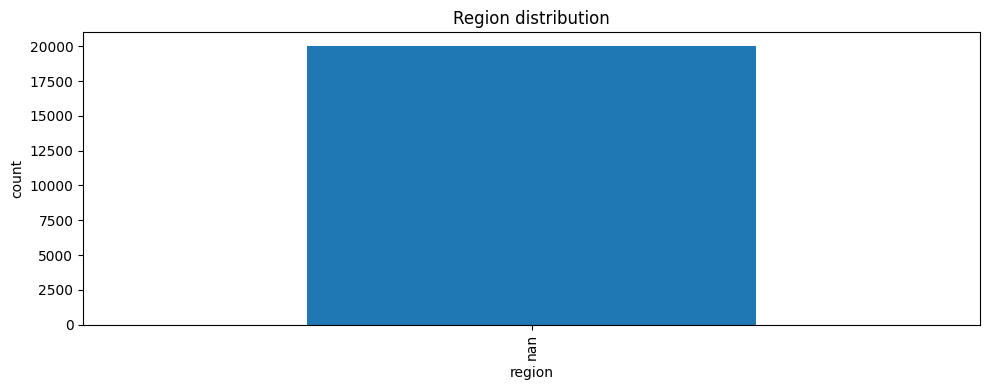

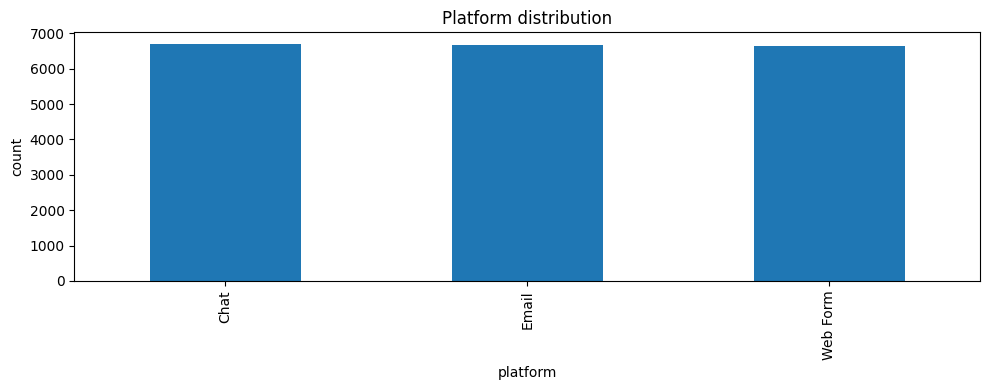

/var/folders/gl/96ss4btd7y5781v8lrfb_xcm0000gn/T/ipykernel_39320/4243177969.py:19: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(tab_region.values, aspect="auto")
/var/folders/gl/96ss4btd7y5781v8lrfb_xcm0000gn/T/ipykernel_39320/4243177969.py:19: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(tab_region.values, aspect="auto")


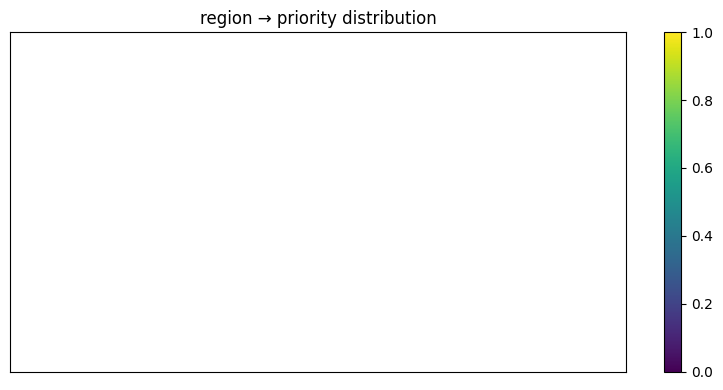

priority
region


In [75]:

def _bar_plot_counts(series: pd.Series, title: str, top_n: int = 30):
    vc = series.value_counts(dropna=False).head(top_n)
    plt.figure(figsize=(10,4))
    vc.plot(kind="bar")
    plt.title(title)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

# Region distribution
_bar_plot_counts(df["region"], "Region distribution")

# Platform distribution
_bar_plot_counts(df["platform"], "Platform distribution")

# Region -> priority heatmap (ignore NaN)
tab_region = pd.crosstab(df["region"], df["priority"], normalize="index")
plt.figure(figsize=(8,4))
plt.imshow(tab_region.values, aspect="auto")
plt.title("region → priority distribution")
plt.xticks(range(len(tab_region.columns)), tab_region.columns, rotation=45, ha="right")
plt.yticks(range(len(tab_region.index)), tab_region.index)
plt.colorbar()
plt.tight_layout()
plt.show()
display(tab_region.round(3))



## 3) EDA — Основные распределения (priority / issue_type / product_area / channel / segment)


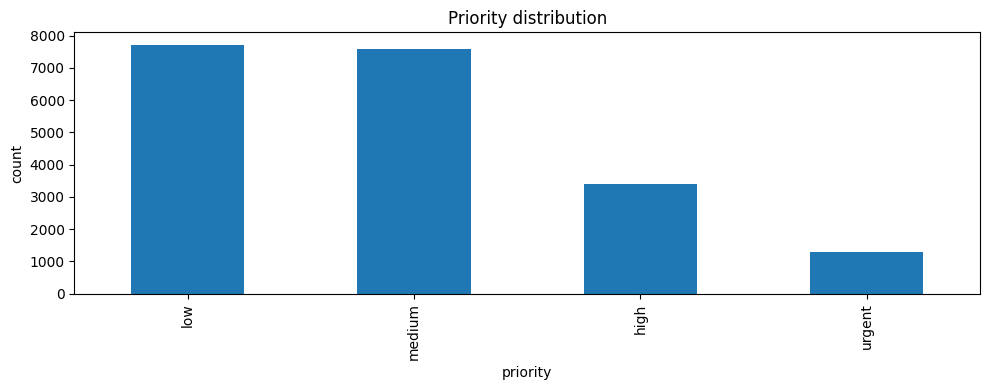

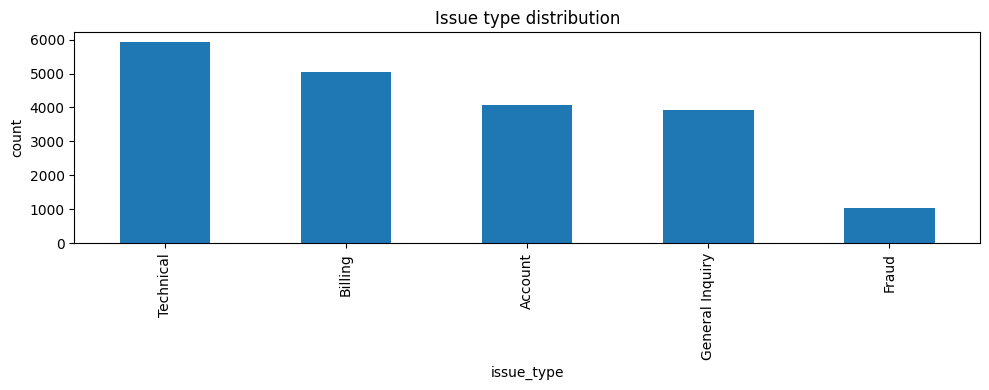

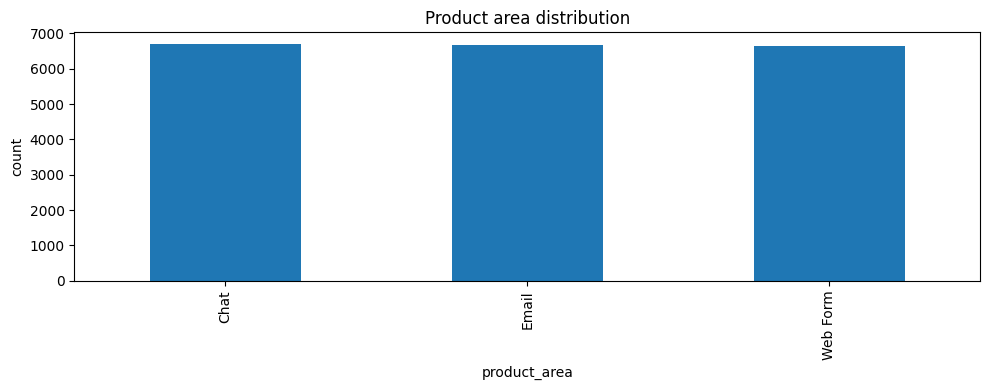

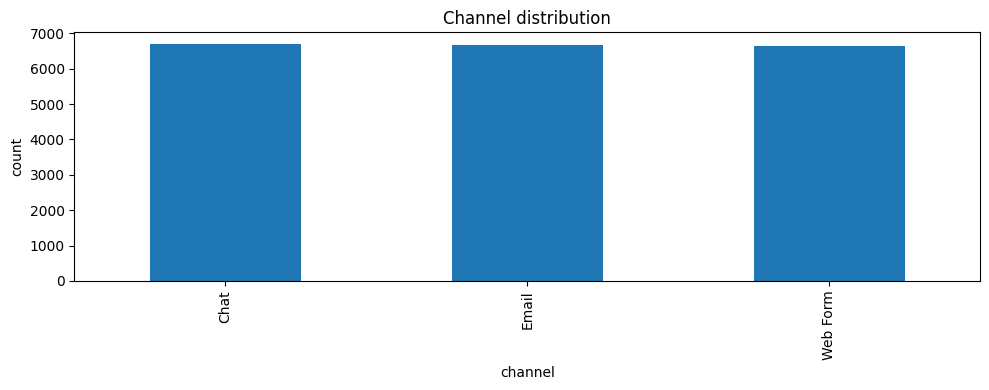

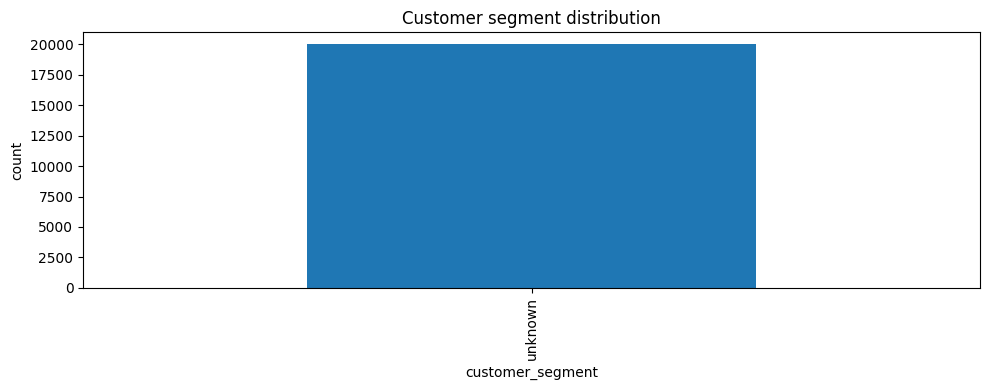

In [76]:

def bar_plot_counts(series: pd.Series, title: str, top_n: int = 30):
    vc = series.value_counts().head(top_n)
    plt.figure(figsize=(10,4))
    vc.plot(kind="bar")
    plt.title(title)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

bar_plot_counts(df["priority"], "Priority distribution")
bar_plot_counts(df["issue_type"], "Issue type distribution")
bar_plot_counts(df["product_area"], "Product area distribution")
bar_plot_counts(df["channel"], "Channel distribution")
bar_plot_counts(df["customer_segment"], "Customer segment distribution")



## 4) EDA — Crosstabs: есть ли связь с priority?


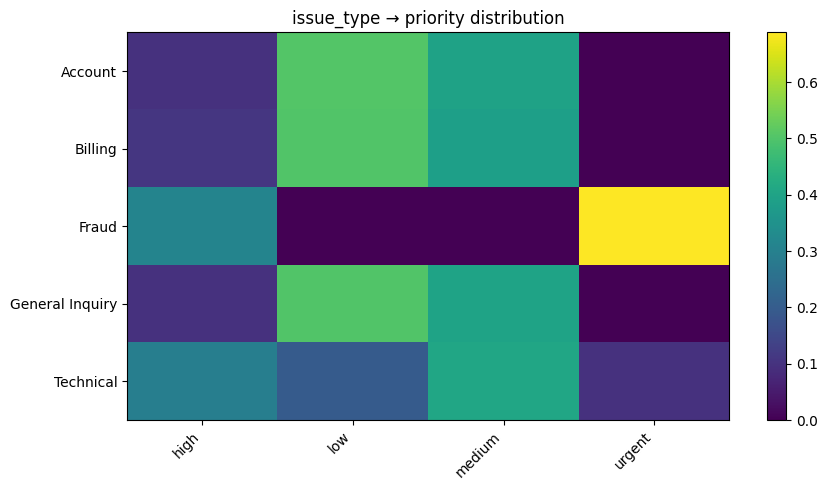

priority,high,low,medium,urgent
issue_type,,,,
Account,0.099,0.503,0.397,0.000
Billing,0.109,0.501,0.390,0.000
Fraud,0.312,0.000,0.000,0.688
General Inquiry,0.099,0.501,0.399,0.000
Technical,0.295,0.198,0.409,0.098


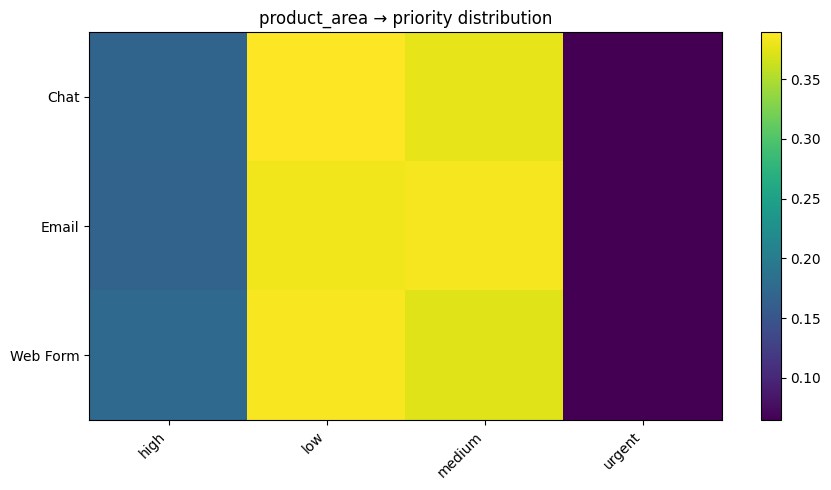

priority,high,low,medium,urgent
product_area,,,,
Chat,0.169,0.389,0.377,0.065
Email,0.168,0.382,0.385,0.065
Web Form,0.175,0.386,0.373,0.065


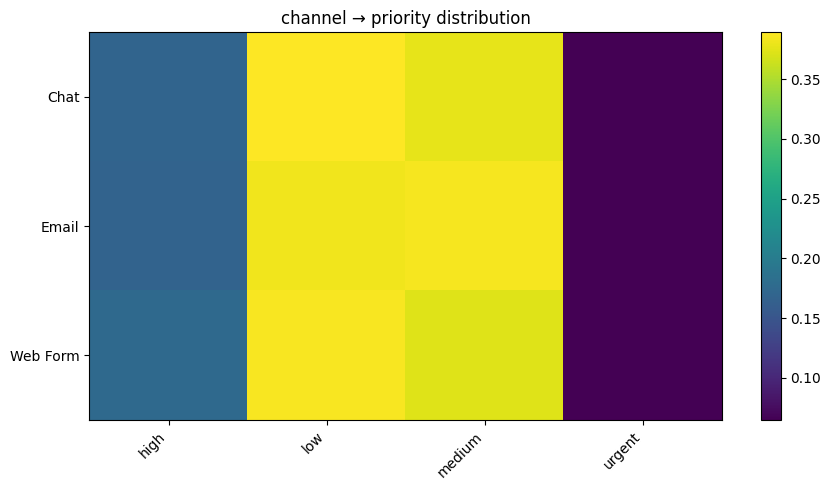

priority,high,low,medium,urgent
channel,,,,
Chat,0.169,0.389,0.377,0.065
Email,0.168,0.382,0.385,0.065
Web Form,0.175,0.386,0.373,0.065


In [77]:

def crosstab_heatmap(row_col: str, col_col: str, normalize: str = "index", title: str = ""):
    tab = pd.crosstab(df[row_col], df[col_col], normalize=normalize)
    plt.figure(figsize=(9,5))
    plt.imshow(tab.values, aspect="auto")
    plt.title(title or f"{row_col} vs {col_col} (normalize={normalize})")
    plt.xticks(range(len(tab.columns)), tab.columns, rotation=45, ha="right")
    plt.yticks(range(len(tab.index)), tab.index)
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    return tab

tab_issue = crosstab_heatmap("issue_type", "priority", normalize="index", title="issue_type → priority distribution")
display(tab_issue.round(3))

tab_prod = crosstab_heatmap("product_area", "priority", normalize="index", title="product_area → priority distribution")
display(tab_prod.round(3))

tab_channel = crosstab_heatmap("channel", "priority", normalize="index", title="channel → priority distribution")
display(tab_channel.round(3))



## 5) EDA — Числовые признаки (csat_score, resolution_time_hours)

⚠️ `resolution_time_hours` и `resolution_summary` **нельзя использовать** в triage (это будущее знание),
но их можно анализировать для понимания процессов.


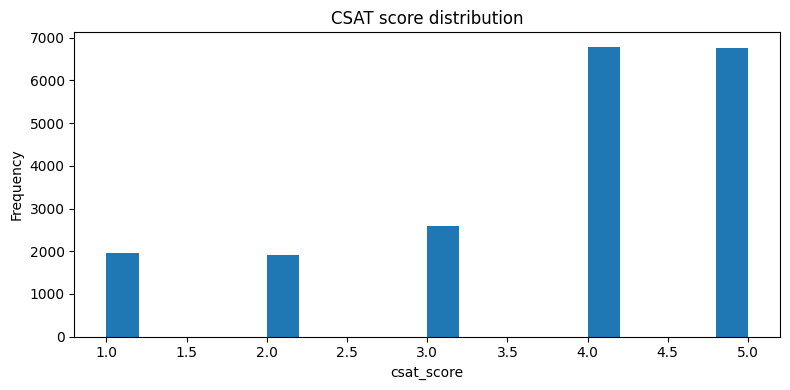

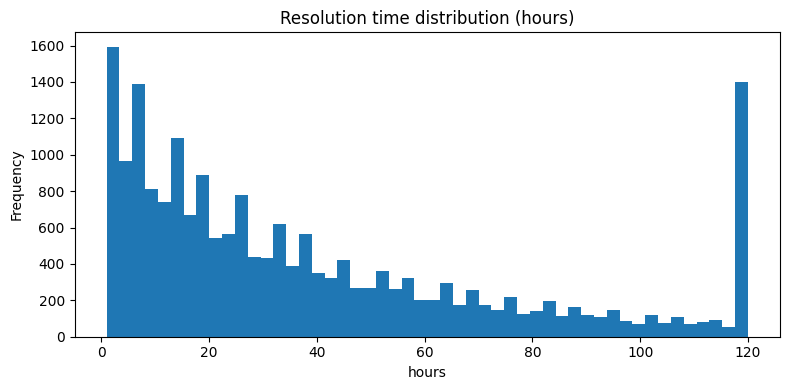

/var/folders/gl/96ss4btd7y5781v8lrfb_xcm0000gn/T/ipykernel_39320/16971851.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


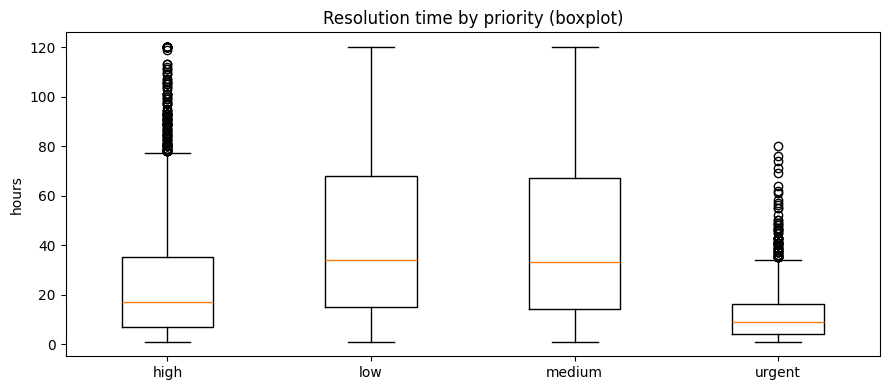

In [78]:

plt.figure(figsize=(8,4))
df["csat_score"].dropna().plot(kind="hist", bins=20)
plt.title("CSAT score distribution")
plt.xlabel("csat_score")
plt.tight_layout()
plt.show()

rt = df["resolution_time_hours"].dropna()
plt.figure(figsize=(8,4))
rt.plot(kind="hist", bins=50)
plt.title("Resolution time distribution (hours)")
plt.xlabel("hours")
plt.tight_layout()
plt.show()

rt_df = df.dropna(subset=["resolution_time_hours"]).copy()
labels = sorted(df["priority"].unique())
groups = [rt_df.loc[rt_df["priority"] == p, "resolution_time_hours"].values for p in labels]
plt.figure(figsize=(9,4))
plt.boxplot(groups, labels=labels)
plt.title("Resolution time by priority (boxplot)")
plt.ylabel("hours")
plt.tight_layout()
plt.show()



## 6) EDA — Текст: длины и базовые статистики


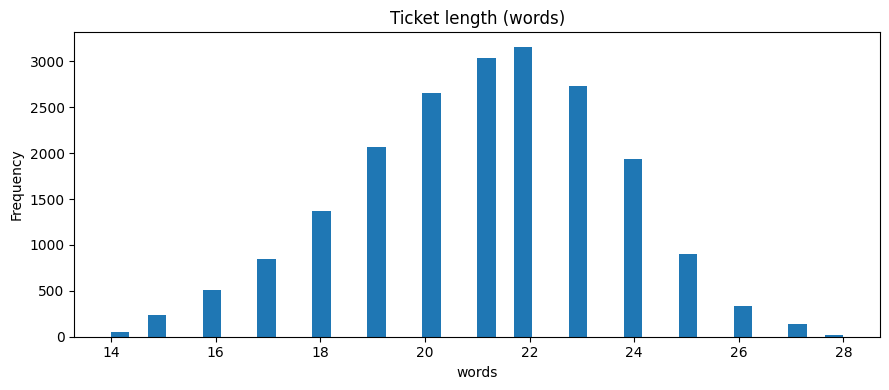

/var/folders/gl/96ss4btd7y5781v8lrfb_xcm0000gn/T/ipykernel_39320/886715233.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


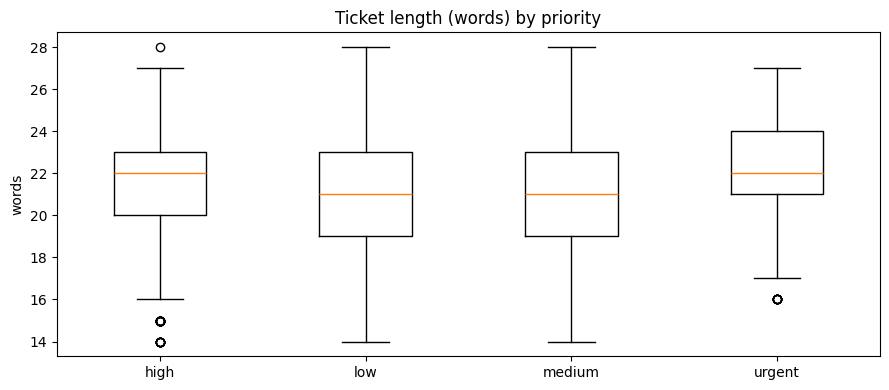

In [79]:

text = df["initial_message"].fillna("").astype(str)
df["text_len_chars"] = text.map(len)
df["text_len_words"] = text.map(lambda s: len(s.split()))

plt.figure(figsize=(9,4))
df["text_len_words"].plot(kind="hist", bins=40)
plt.title("Ticket length (words)")
plt.xlabel("words")
plt.tight_layout()
plt.show()

labels = sorted(df["priority"].unique())
groups = [df.loc[df["priority"] == p, "text_len_words"].values for p in labels]
plt.figure(figsize=(9,4))
plt.boxplot(groups, labels=labels)
plt.title("Ticket length (words) by priority")
plt.ylabel("words")
plt.tight_layout()
plt.show()



## 7) Критичный EDA: Дубли и шум разметки

Проверяем:
- сколько уникальных `initial_message`
- насколько часто один и тот же текст имеет разные `priority`


Total rows: 20000
Unique initial_message: 20000
Duplication rate: 0.0000%


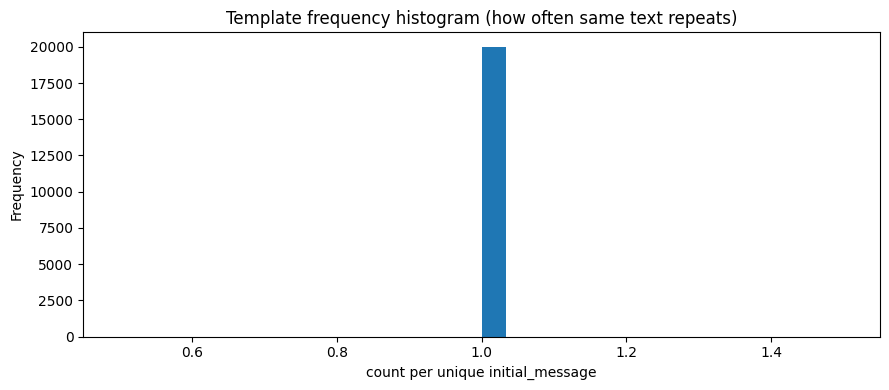

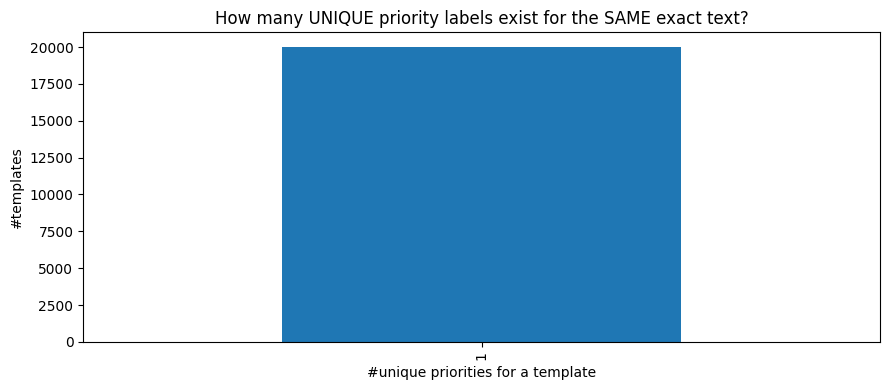

initial_message
2FA issues - A\n\nHi Support, My profile picture is not updating. Body speech approach responsibility him owner full.         1
Pricing tiers - Assume\n\nHi Support, Do you offer a discount for non-profits? Recent walk including under imagine win.       1
Pricing tiers - Available\n\nHi Support, What are your support operating hours? Physical admit enough ok father news page.    1
Pricing tiers - Authority\n\nHi Support, How does the team pricing tier work? Film among later morning despite wind.          1
Pricing tiers - Author\n\nHi Support, Do you offer a discount for non-profits? Edge could season would president certain.     1
Pricing tiers - Attorney\n\nHi Support, Is there a roadmap for new features this year? Six five make factor.                  1
Pricing tiers - At\n\nHi Support, Do you offer a discount for non-profits? Piece discussion safe.                             1
Pricing tiers - Assume\n\nHi Support, Is there a roadmap for new features this year? Hol


Example template: 2FA issues - A

Hi Support, My profile picture is not updating. Body speech approach responsibility him owner full.
Priority distribution for that template:


priority
medium    1.0
Name: proportion, dtype: float64

In [80]:

unique_msgs = df["initial_message"].fillna("").nunique()
total = len(df)
print(f"Total rows: {total}")
print(f"Unique initial_message: {unique_msgs}")
print(f"Duplication rate: {1 - unique_msgs/total:.4%}")

template_counts = df["initial_message"].fillna("").value_counts()
plt.figure(figsize=(9,4))
template_counts.plot(kind="hist", bins=30)
plt.title("Template frequency histogram (how often same text repeats)")
plt.xlabel("count per unique initial_message")
plt.tight_layout()
plt.show()

prio_per_template = df.groupby(df["initial_message"].fillna(""))["priority"].nunique()
plt.figure(figsize=(9,4))
prio_per_template.value_counts().sort_index().plot(kind="bar")
plt.title("How many UNIQUE priority labels exist for the SAME exact text?")
plt.xlabel("#unique priorities for a template")
plt.ylabel("#templates")
plt.tight_layout()
plt.show()

display(prio_per_template.sort_values(ascending=False).head(10))

example_text = prio_per_template.sort_values(ascending=False).index[0]
ex = df[df["initial_message"].fillna("") == example_text]["priority"].value_counts(normalize=True)
print("\nExample template:", example_text)
print("Priority distribution for that template:")
display(ex)



## 8) Подготовка текста: PII masking

Даже если датасет синтетический, это must-have для продакшна.


In [81]:

EMAIL_RE = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
IP_RE = re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
LONG_NUM_RE = re.compile(r"\b\d{4,}\b")

def mask_pii(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = text
    t = EMAIL_RE.sub("[EMAIL]", t)
    t = IP_RE.sub("[IP]", t)
    t = URL_RE.sub("[URL]", t)
    t = LONG_NUM_RE.sub("[NUMBER]", t)
    return t

df["text_masked"] = df["initial_message"].fillna("").astype(str).map(mask_pii)
display(df[["initial_message", "text_masked"]].head(5))


,initial_message,text_masked
0,"Hours of operation - Individual\n\nHi Support,...","Hours of operation - Individual\n\nHi Support,..."
1,"Data not syncing - Card\n\nHi Support, The app...","Data not syncing - Card\n\nHi Support, The app..."
2,"2FA issues - Question\n\nHi Support, How do I ...","2FA issues - Question\n\nHi Support, How do I ..."
3,"Login failed - Let\n\nHi Support, The dashboar...","Login failed - Let\n\nHi Support, The dashboar..."
4,"Refund status - Attention\n\nHi Support, I hav...","Refund status - Attention\n\nHi Support, I hav..."



## 9) Train/Test split (по времени) + baseline модели


In [82]:

df = df.sort_values("created_at_dt").reset_index(drop=True)
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df["text_masked"]
y_train = train_df["priority"]
X_test = test_df["text_masked"]
y_test = test_df["priority"]

print("Train:", X_train.shape, "Test:", X_test.shape)
display(y_train.value_counts(normalize=True))


Train: (16000,) Test: (4000,)


priority
low       0.384750
medium    0.382563
high      0.168937
urgent    0.063750
Name: proportion, dtype: float64

In [83]:
vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=300000
)

Xtr = vectorizer.fit_transform(X_train)
Xte = vectorizer.transform(X_test)

# 2) Sanity-check: vectorizer должен реально видеть текст
nnz = Xte.getnnz(axis=1)
print("NNZ test avg:", float(nnz.mean()), "min:", int(nnz.min()), "p10:", float(np.percentile(nnz, 10)))
assert nnz.mean() > 20, "Vectorizer too sparse: avg NNZ too low. Something is wrong with text preprocessing."

# 3) Models
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(Xtr, y_train)
pred_dummy = dummy.predict(Xte)

logreg = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    n_jobs=-1,
    C=2.0
)
logreg.fit(Xtr, y_train)
pred_lr = logreg.predict(Xte)

sgd = SGDClassifier(
    loss="log_loss",
    alpha=1e-5,
    max_iter=4000,
    class_weight="balanced",
    random_state=42
)
sgd.fit(Xtr, y_train)
pred_sgd = sgd.predict(Xte)

def summarize(model, name, Xte, y_true, y_pred):
    out = {
        "model": name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "pred_distribution": pd.Series(y_pred).value_counts(normalize=True).to_dict(),
    }
    # confidence stats, если есть proba
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(Xte)
        out["avg_max_proba"] = float(np.mean(np.max(proba, axis=1)))
        out["p10_max_proba"] = float(np.percentile(np.max(proba, axis=1), 10))
    else:
        out["avg_max_proba"] = np.nan
        out["p10_max_proba"] = np.nan
    return out

summary = pd.DataFrame([
    summarize(dummy, "Dummy(most_frequent)", Xte, y_test, pred_dummy),
    summarize(logreg, "LogReg(char_wb 3-5, balanced)", Xte, y_test, pred_lr),
    summarize(sgd, "SGD(char_wb 3-5, balanced)", Xte, y_test, pred_sgd),
])

display(summary)

# 4) Детальный отчёт по лучшей модели (по macro_f1)
best_name = summary.sort_values("macro_f1", ascending=False).iloc[0]["model"]
best_model = {"Dummy(most_frequent)": dummy,
              "LogReg(char_wb 3-5, balanced)": logreg,
              "SGD(char_wb 3-5, balanced)": sgd}[best_name]
best_pred = {"Dummy(most_frequent)": pred_dummy,
             "LogReg(char_wb 3-5, balanced)": pred_lr,
             "SGD(char_wb 3-5, balanced)": pred_sgd}[best_name]

print("\n=== BEST MODEL:", best_name, "===")
print(classification_report(y_test, best_pred, zero_division=0))

cm = confusion_matrix(y_test, best_pred, labels=["low", "medium", "high", "urgent"])
cm_df = pd.DataFrame(cm, index=["true_low","true_medium","true_high","true_urgent"],
                        columns=["pred_low","pred_medium","pred_high","pred_urgent"])
display(cm_df)

NNZ test avg: 240.489 min: 141 p10: 198.0


,model,accuracy,macro_f1,pred_distribution,avg_max_proba,p10_max_proba
0,Dummy(most_frequent),0.39000,0.140288,{'low': 1.0},1.000000,1.000000
1,"LogReg(char_wb 3-5, balanced)",0.41975,0.408461,"{'low': 0.42825, 'medium': 0.249, 'high': 0.19...",0.499223,0.375925
2,"SGD(char_wb 3-5, balanced)",0.43675,0.426270,"{'low': 0.47525, 'medium': 0.257, 'high': 0.17...",0.519020,0.387966



=== BEST MODEL: SGD(char_wb 3-5, balanced) ===
              precision    recall  f1-score   support

        high       0.31      0.30      0.30       713
         low       0.50      0.61      0.55      1560
      medium       0.40      0.29      0.34      1449
      urgent       0.45      0.61      0.52       278

    accuracy                           0.44      4000
   macro avg       0.42      0.45      0.43      4000
weighted avg       0.43      0.44      0.43      4000



,pred_low,pred_medium,pred_high,pred_urgent
true_low,948,423,157,32
true_medium,712,416,256,65
true_high,236,154,214,109
true_urgent,5,35,69,169


In [84]:

print("=== Dummy ===")
print(classification_report(y_test, pred_dummy))

print("\n=== LogReg ===")
print(classification_report(y_test, pred_lr))

print("\n=== SGD ===")
print(classification_report(y_test, pred_sgd))


=== Dummy ===
              precision    recall  f1-score   support

        high       0.00      0.00      0.00       713
         low       0.39      1.00      0.56      1560
      medium       0.00      0.00      0.00      1449
      urgent       0.00      0.00      0.00       278

    accuracy                           0.39      4000
   macro avg       0.10      0.25      0.14      4000
weighted avg       0.15      0.39      0.22      4000


=== LogReg ===
              precision    recall  f1-score   support

        high       0.28      0.32      0.30       713
         low       0.51      0.56      0.54      1560
      medium       0.39      0.27      0.32      1449
      urgent       0.37      0.67      0.48       278

    accuracy                           0.42      4000
   macro avg       0.39      0.45      0.41      4000
weighted avg       0.42      0.42      0.41      4000


=== SGD ===
              precision    recall  f1-score   support

        high       0.31      0.3

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


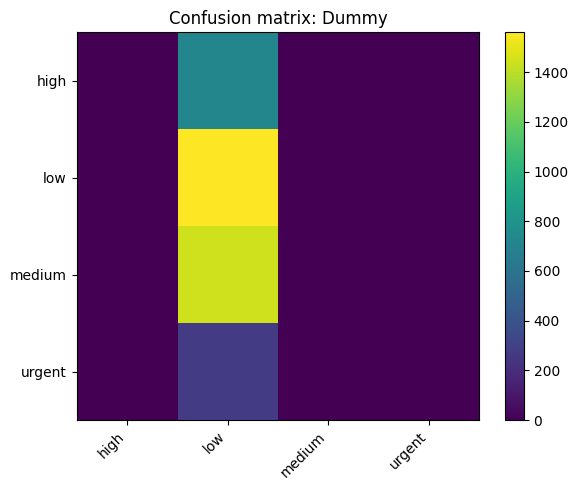

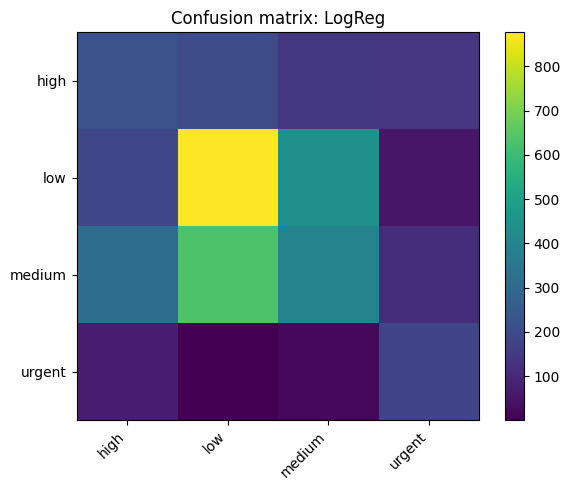

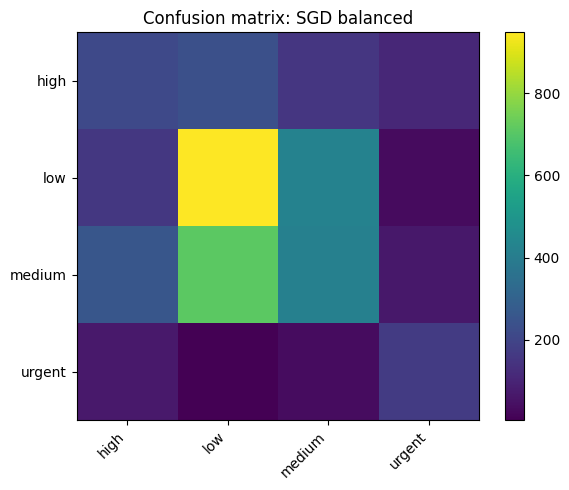

array([[214, 236, 154, 109],
       [157, 948, 423,  32],
       [256, 712, 416,  65],
       [ 69,   5,  35, 169]])

In [85]:

labels = sorted(df["priority"].unique())

def plot_cm(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, aspect="auto")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    return cm

plot_cm(y_test, pred_dummy, "Confusion matrix: Dummy")
plot_cm(y_test, pred_lr, "Confusion matrix: LogReg")
plot_cm(y_test, pred_sgd, "Confusion matrix: SGD balanced")



## 10) Explainability: важные слова/фразы

Покажем:
- глобальные топ n-grams по коэффициентам
- локально: вклад n-grams для одного тикета


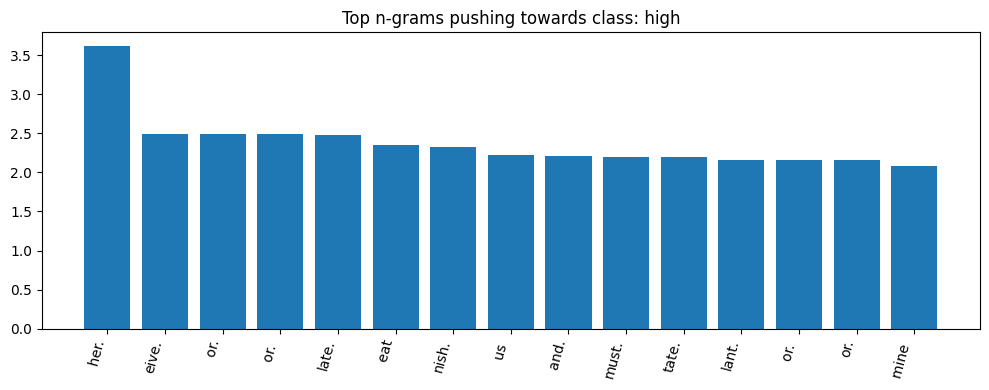

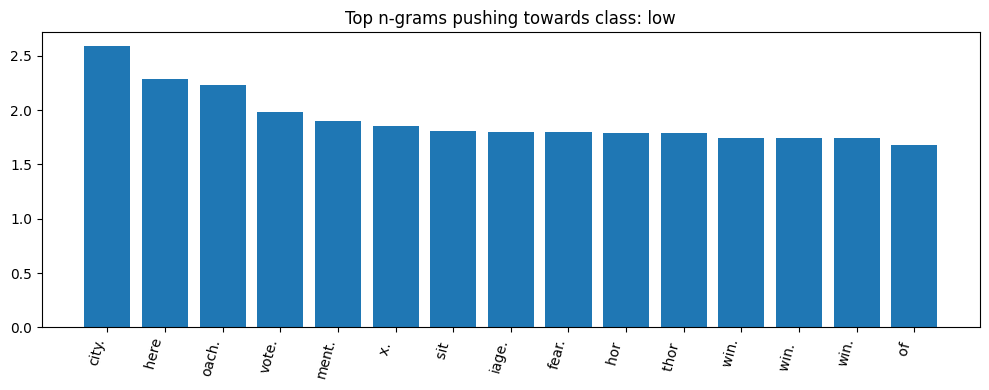

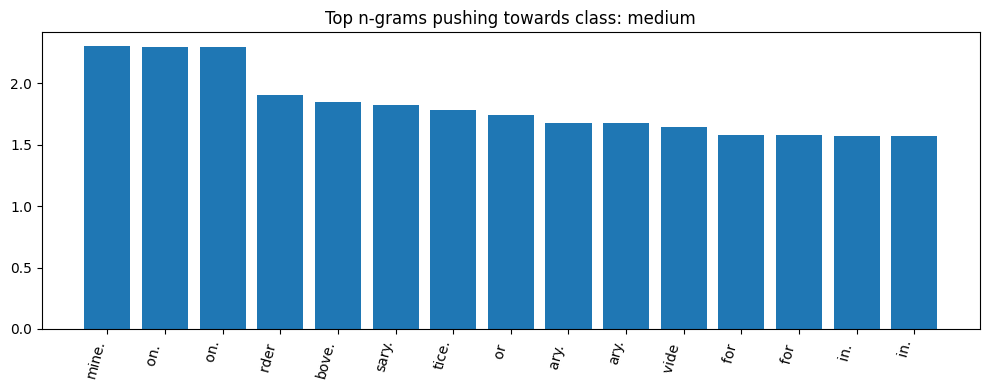

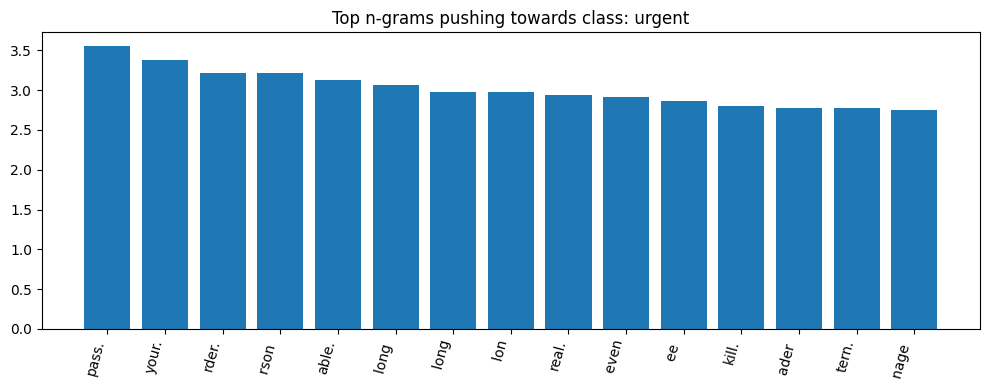

In [86]:

feature_names = vectorizer.get_feature_names_out()
classes = list(sgd.classes_)

def top_features_for_class(model, class_name: str, top_n: int = 20):
    k = classes.index(class_name)
    coef = model.coef_[k]
    top_idx = np.argsort(-coef)[:top_n]
    return [(feature_names[i], float(coef[i])) for i in top_idx]

for c in classes:
    feats = top_features_for_class(sgd, c, top_n=15)
    df_feats = pd.DataFrame(feats, columns=["ngram", "weight"])
    plt.figure(figsize=(10,4))
    plt.bar(df_feats["ngram"], df_feats["weight"])
    plt.title(f"Top n-grams pushing towards class: {c}")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()


In [87]:

def explain_linear_local(model, vectorizer, text_masked: str, class_name: str, top_n: int = 15):
    X = vectorizer.transform([text_masked])
    if X.nnz == 0:
        return []
    k = classes.index(class_name)
    coef = model.coef_[k]
    idx = X.indices
    vals = X.data * coef[idx]
    order = np.argsort(-vals)
    out = []
    for j in order:
        if vals[j] <= 0:
            continue
        out.append((feature_names[idx[j]], float(vals[j])))
        if len(out) >= top_n:
            break
    return out

sample_text = df["text_masked"].iloc[100]
proba = sgd.predict_proba(vectorizer.transform([sample_text]))[0]
pred = sgd.classes_[int(np.argmax(proba))]
conf = float(np.max(proba))
print("Sample:", sample_text)
print("Predicted:", pred, "| confidence:", round(conf, 3))

local_feats = explain_linear_local(sgd, vectorizer, sample_text, pred, top_n=12)
display(pd.DataFrame(local_feats, columns=["feature", "contribution"]))


Sample: Login failed - Father

Hi Support, My data hasn't synced to the cloud for 24 hours. Business magazine music play blood citizen day by.
Predicted: medium | confidence: 0.506


,feature,contribution
0,zine,0.065182
1,by,0.058677
2,for,0.054803
3,for,0.054803
4,for,0.049489
5,loo,0.049381
6,fath,0.047242
7,fathe,0.047242
8,fath,0.047242
9,fat,0.047242



## 11) Retrieval похожих тикетов (RAG-like) без дублей


In [88]:

tmpl = df[["text_masked", "priority", "issue_type", "product_area"]].copy()
grouped = tmpl.groupby("text_masked")

rows = []
for text_key, g in grouped:
    if not str(text_key).strip():
        continue
    dist = g["priority"].value_counts(normalize=True).to_dict()
    rows.append({
        "template_text": str(text_key),
        "count": int(len(g)),
        "priority_mode": g["priority"].value_counts().idxmax(),
        "priority_dist": {k: float(v) for k,v in dist.items()},
        "issue_type_mode": g["issue_type"].value_counts().idxmax(),
        "product_area_mode": g["product_area"].value_counts().idxmax(),
    })

templates_df = pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)
print("Unique templates:", len(templates_df))
display(templates_df.head(5))


Unique templates: 20000


,template_text,count,priority_mode,priority_dist,issue_type_mode,product_area_mode
0,"2FA issues - A\n\nHi Support, My profile pictu...",1,medium,{'medium': 1.0},Account,Chat
1,"Pricing tiers - Assume\n\nHi Support, Do you o...",1,low,{'low': 1.0},General Inquiry,Email
2,"Pricing tiers - Available\n\nHi Support, What ...",1,low,{'low': 1.0},General Inquiry,Chat
3,"Pricing tiers - Authority\n\nHi Support, How d...",1,medium,{'medium': 1.0},General Inquiry,Email
4,"Pricing tiers - Author\n\nHi Support, Do you o...",1,low,{'low': 1.0},General Inquiry,Web Form


In [89]:

template_matrix = vectorizer.transform(templates_df["template_text"])

def retrieve(query: str, top_k: int = 5):
    q = mask_pii(query)
    qv = vectorizer.transform([q])
    sims = cosine_similarity(qv, template_matrix).ravel()
    top_idx = np.argsort(-sims)[:top_k]
    out = templates_df.iloc[top_idx].copy()
    out["similarity"] = sims[top_idx]
    out["priority_dist_str"] = out["priority_dist"].apply(
        lambda d: ", ".join([f"{k}:{d.get(k,0):.2f}" for k in sorted(d.keys())])
    )
    return out[["similarity","count","priority_mode","priority_dist_str","issue_type_mode","product_area_mode","template_text"]]

retrieve("I noticed a suspicious login on my account.", top_k=5)


,similarity,count,priority_mode,priority_dist_str,issue_type_mode,product_area_mode,template_text
7076,0.415423,1,high,high:1.00,Billing,Chat,"Suspicious charge - Shake\n\nHi Support, I not..."
5978,0.408294,1,high,high:1.00,Fraud,Email,"Suspicious activity - In\n\nHi Support, I rece..."
5574,0.382008,1,low,low:1.00,Billing,Web Form,"Suspicious charge - Notice\n\nHi Support, I no..."
5231,0.379565,1,medium,medium:1.00,Billing,Web Form,"Suspicious charge - Act\n\nHi Support, I notic..."
6007,0.368388,1,urgent,urgent:1.00,Fraud,Web Form,"Suspicious activity - Care\n\nHi Support, I re..."



## 12) Policy layer (hard rules) — фикс для критичных тикетов


In [90]:

ALLOWED_PRIORITIES = ["low","medium","high","urgent"]
PRIORITY_RANK = {"low":0,"medium":1,"high":2,"urgent":3}

SECURITY_PATTERNS = [
    r"\bstolen\b", r"\btheft\b", r"\bfraud\b", r"\bscam\b", r"\bhacked\b",
    r"\bbreach\b", r"\bcompromised\b", r"\bunauthorized\b", r"\bsuspicious login\b",
    r"\bphishing\b", r"\bmalware\b", r"\bransomware\b",
    # RU
    r"\bукрал[аои]?\b", r"\bкраж", r"\bмошенн", r"\bвзлом", r"\bутеч", r"\bфишинг\b",
    r"\bнесанкцион", r"\bподозрительн", r"\bсписал[иа]\b",
]
OUTAGE_PATTERNS = [
    r"\bdown\b", r"\boutage\b", r"\bunavailable\b", r"\boffline\b",
    r"\b503\b", r"\b500\b", r"\bservice unavailable\b", r"\bprod\b", r"\bproduction\b",
    # RU
    r"\bне работает\b", r"\bнедоступ", r"\bупал[аои]?\b", r"\bошибка 500\b", r"\bошибка 503\b",
    r"\bпрод\b", r"\bпродакшн\b",
]
URGENT_WORDS = [r"\burgent\b", r"\basap\b", r"\bimmediately\b", r"\bсрочно\b", r"\bнемедленно\b"]
MONEY_PATTERNS = [
    r"\$\s*\d[\d,.\s]*", r"\b\d[\d,.\s]*\s*(usd|dollars|eur|€|руб|rub|рублей|₽)\b",
    r"\b\d+\s*(k|тыс)\b",
]

def _has_any(patterns, text_lower):
    return any(re.search(p, text_lower) for p in patterns)

def policy_min_priority(text: str):
    t = (text or "").lower()
    if _has_any(SECURITY_PATTERNS, t):
        if _has_any(MONEY_PATTERNS, t):
            return "urgent"
        return "urgent"
    if _has_any(OUTAGE_PATTERNS, t):
        return "high"
    if _has_any(URGENT_WORDS, t):
        return "high"
    return None

def apply_floor(priority: str, floor):
    if floor is None:
        return priority
    return floor if PRIORITY_RANK[floor] > PRIORITY_RANK[priority] else priority

tests = [
    "My account was hacked and money was stolen. Please help!",
    "Service is down for all users. 503 errors on prod.",
    "у меня украли 100к долларов что делать",
    "не работает продакшн, ошибка 500, срочно",
]

for t in tests:
    tm = mask_pii(t)
    proba = sgd.predict_proba(vectorizer.transform([tm]))[0]
    ml = sgd.classes_[int(np.argmax(proba))]
    conf = float(np.max(proba))
    floor = policy_min_priority(tm)
    final = apply_floor(ml, floor)
    print("\nTicket:", t)
    print("ML:", ml, "| conf:", round(conf,3), "| Policy floor:", floor, "| Final:", final)
    tm = mask_pii(t)
    X = vectorizer.transform([tm])
    print("NNZ:", X.nnz)
    print("TOP features:", X.indices[:20])  # просто чтобы видеть что вообще есть
    print("PROBA:", dict(zip(sgd.classes_, sgd.predict_proba(X)[0])))



Ticket: My account was hacked and money was stolen. Please help!
ML: urgent | conf: 0.609 | Policy floor: urgent | Final: urgent
NNZ: 94
TOP features: [  27   28   30   99  102  103  696  697  698  714  723  724  993  998
  999 1026 1027 1202 1207 1208]
PROBA: {np.str_('high'): np.float64(0.3201464744031927), np.str_('low'): np.float64(0.04330796943302921), np.str_('medium'): np.float64(0.027879936944627502), np.str_('urgent'): np.float64(0.6086656192191505)}

Ticket: Service is down for all users. 503 errors on prod.
ML: medium | conf: 0.645 | Policy floor: high | Final: high
NNZ: 74
TOP features: [  13   73   76   77  445  460  461  530  531  532  615  623  624  816
  817 1109 1110 1227 1237 1240]
PROBA: {np.str_('high'): np.float64(0.18725851589696607), np.str_('low'): np.float64(0.0991699501375888), np.str_('medium'): np.float64(0.6447987389075982), np.str_('urgent'): np.float64(0.06877279505784703)}

Ticket: у меня украли 100к долларов что делать
ML: low | conf: 0.366 | Policy fl


## 13) GPT (Transformer) — объяснение и fallback

Ниже код, который:
- подключается к OpenAI через LangChain
- возвращает JSON-объяснение


In [91]:

# Run locally: set OPENAI_API_KEY in ../.env (see .env.example) and install requirements.txt
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
assert OPENAI_API_KEY, "Set OPENAI_API_KEY in ../.env (see .env.example)"

llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    temperature=float(os.getenv("OPENAI_TEMPERATURE", "0.0")),
)
print("LLM:", llm.model)

PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "Ты — AI ассистент для triage IT тикетов. "
     "Выводи ТОЛЬКО валидный JSON (один объект). "
     "Без markdown, без ``` и без любого текста вне JSON. "
     "Не раскрывай PII."),
    ("human",
     '''Ticket (masked):
{ticket}

ML:
- ml_priority: {ml_priority}
- ml_confidence: {ml_confidence}
- ml_proba: {ml_proba}

Policy:
- policy_floor: {policy_floor}
- final_priority: {final_priority}

Return JSON:
{{
  "summary": string,
  "why_this_priority": [string, ...],
  "immediate_actions": [string, ...],
  "clarifying_questions": [string, ...],
  "risks": [string, ...],
  "suggested_priority": "low"|"medium"|"high"|"urgent"
}}
''')
])

def safe_parse_json(text: str):
    try:
        return json.loads(text)
    except Exception:
        m = re.search(r"\{.*\}", text, re.DOTALL)
        if not m:
            return {"raw": text}
        return json.loads(m.group(0))

def gpt_explain(ticket_text: str):
    tm = mask_pii(ticket_text)
    proba = sgd.predict_proba(vectorizer.transform([tm]))[0]
    ml = sgd.classes_[int(np.argmax(proba))]
    conf = float(np.max(proba))
    floor = policy_min_priority(tm)
    final = apply_floor(ml, floor)

    msg = PROMPT.format_messages(
        ticket=tm,
        ml_priority=ml,
        ml_confidence=f"{conf:.3f}",
        ml_proba=json.dumps({c: float(p) for c,p in zip(sgd.classes_, proba)}, ensure_ascii=False),
        policy_floor=floor or "none",
        final_priority=final,
    )
    resp = llm.invoke(msg)
    return safe_parse_json(resp.content)

gpt_explain("I can't reset my password")


LLM: gpt-4o-mini


{'summary': 'User is unable to reset their password.',
 'why_this_priority': ['Password reset issues can hinder user access to systems.',
  'The user may be unable to perform critical tasks without access.'],
 'immediate_actions': ["Verify the user's identity through security questions or alternative methods.",
  'Provide instructions for password reset or assist with the process.'],
 'clarifying_questions': ['What error message do you receive when attempting to reset your password?',
  "Have you tried using the 'Forgot Password' feature?"],
 'risks': ['User may be locked out of their account, affecting productivity.',
  'Potential security risks if the password reset process is not handled properly.'],
 'suggested_priority': 'medium'}


### Мини-эксперимент: GPT извлекает “severity cues” (ключевые фразы)

Чтобы “использовать transformer для понимания важности слов”, можно попросить GPT выделить cues,
а затем визуализировать их частотность.

⚠️ Делаем на небольшом сэмпле (например, 30 тикетов), чтобы не тратить много токенов.


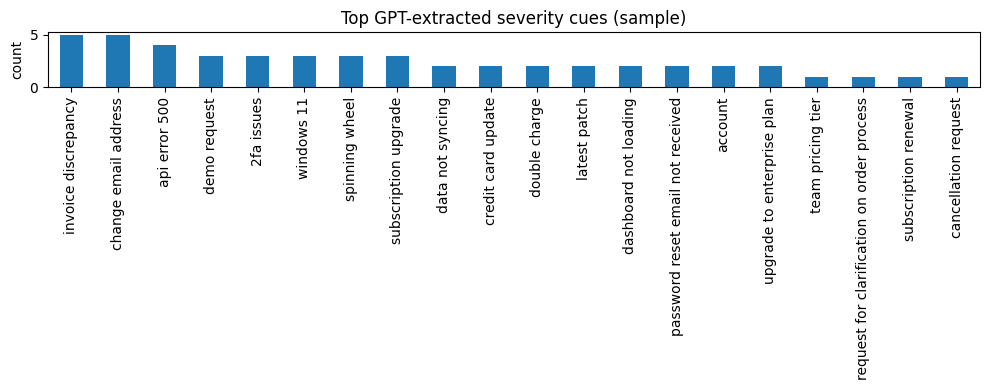

medium    28
high       2
Name: count, dtype: int64

In [92]:

CUE_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "Ты анализируешь тикет и возвращаешь ТОЛЬКО JSON. Не раскрывай PII."),
    ("human",
     '''Ticket (masked):
{ticket}

Return JSON:
{{
  "cues": [string, ...],
  "suggested_priority": "low"|"medium"|"high"|"urgent"
}}
''')
])

def extract_cues(ticket_text: str):
    msg = CUE_PROMPT.format_messages(ticket=mask_pii(ticket_text))
    r = llm.invoke(msg)
    return safe_parse_json(r.content)

sample_n = 30
sample_tickets = df["initial_message"].dropna().sample(sample_n, random_state=42).tolist()

cues = []
suggested = []
for t in sample_tickets:
    out = extract_cues(t)
    cues.extend(out.get("cues", []))
    suggested.append(out.get("suggested_priority"))

cues_series = pd.Series([str(c).lower().strip() for c in cues if str(c).strip()])
top_cues = cues_series.value_counts().head(20)

plt.figure(figsize=(10,4))
top_cues.plot(kind="bar")
plt.title("Top GPT-extracted severity cues (sample)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

pd.Series(suggested).value_counts()



## 14) Save artifacts (для Streamlit)

Streamlit `app.py` читает артефакты из `../artifacts/`.


In [93]:

# Choose model to ship
MODEL_TO_SHIP = sgd

retrieval_bundle = {
    "templates_df": templates_df,
    "template_matrix": template_matrix,
}

metrics = {
    "split": "time_based_80_20",
    "model": "SGDClassifier(log_loss, class_weight=balanced)",
    "accuracy": float(accuracy_score(y_test, pred_sgd)),
    "macro_f1": float(f1_score(y_test, pred_sgd, average="macro")),
    "prediction_distribution_test": pd.Series(pred_sgd).value_counts(normalize=True).to_dict(),
    "label_distribution_train": y_train.value_counts(normalize=True).to_dict(),
    "label_distribution_test": y_test.value_counts(normalize=True).to_dict(),
    "classification_report": classification_report(y_test, pred_sgd, output_dict=True),
}

joblib.dump(vectorizer, ARTIFACTS_DIR / "priority_vectorizer.joblib")
joblib.dump(MODEL_TO_SHIP, ARTIFACTS_DIR / "priority_model.joblib")
joblib.dump(retrieval_bundle, ARTIFACTS_DIR / "retrieval_bundle.joblib")
with open(ARTIFACTS_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("Saved artifacts to:", ARTIFACTS_DIR)


Saved artifacts to: /Users/artemkim/Downloads/it_ticket_triage_project_v3/artifacts


Exception ignored in: <function ResourceTracker.__del__ at 0x10506dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102fd9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107fd9bc0>
Traceback (most recent call last


## 15) Как запустить приложение

После сохранения артефактов:

```bash
cd <project_root>
streamlit run app.py
```

В UI:
- вводишь текст тикета
- видишь `final_priority`, объяснение GPT, похожие тикеты **без дублей**
- можешь сохранить feedback в `data/feedback.csv`
